# Missing-value imputation with `LanguageModelImputer`

Because the shared fine-tune learns $p(x_j \mid x_S)$ for arbitrary $j$ and $S$ (see
`00-intro.ipynb`), filling a missing cell is immediate: condition on whatever the row
*does* expose and predict the cell that is absent. For a row split into observed cells $x_O$ and
missing cells $x_M$, the imputer draws from

$$ p\!\left(x_M \mid x_O\right). $$

Unlike column-wise imputers that fit one model per target, a single LM handles every missing
pattern from one fit, and it respects cross-column structure (a wide petal implies a long petal)
rather than imputing each column in isolation.

## Generate vs. score (discretization)

There are two ways to produce the missing cell:

- **Generate** (default): sample the value as text, repeat `n_samples` times, aggregate.
- **Score** (`discretization`): when a column lives on a small, known grid — here `petal width`,
  rounded to 0.1 cm, takes only about twenty distinct values — it is sharper to enumerate the
  candidates and pick the most likely one. The imputer scores each candidate by likelihood and
  reduces the distribution to its **mode**,

$$ \hat{x}_M = \arg\max_{v \,\in\, \text{grid}} \; p\!\left(x_M = v \mid x_O\right), $$

  which is deterministic and avoids spending samples on a continuous range the column never uses.
  `discretization={col: DiscretizationConfig(...)}` applies this per column; any column not listed
  stays on the generative path.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris

from sklm import (
    DiscretizationConfig,
    GenerationConfig,
    JupyterCallback,
    LanguageModelImputer,
    TrainingConfig,
)

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

## Data: knock out ~15% of one column

We round Iris to 0.1 cm and set roughly 15% of the `petal width` cells to `NaN`. Keeping the true
values aside lets us score the imputation at the end.

In [2]:
iris = load_iris(as_frame=True)
frame = iris.data.round(1).rename(columns=lambda c: c.removesuffix(" (cm)"))
target_col = "petal width"

rng = np.random.default_rng(SEED)
mask = rng.random(len(frame)) < 0.15
corrupt = frame.copy()
corrupt.loc[mask, target_col] = np.nan
print(f"missing cells: {int(corrupt.isna().sum().sum())} of {len(frame)}")

missing cells: 23 of 150


## Imputation

`fit_transform` fine-tunes on the rows (using observed cells) and returns the frame with the
`NaN`s filled. We turn on `discretization` for `petal width` with `estimate="mode"`, so that
column is scored, not generated.

In [3]:
from sklm import JSONSerializer, SpacedDigits


filled = LanguageModelImputer(
    model="gpt2-large",
    backend="mlx",
    precision="fp32",
    serializer=JSONSerializer(number=SpacedDigits()),
    discretization={target_col: DiscretizationConfig(bins=0.4, estimate="mode")},
    generation=GenerationConfig(n_samples=6),
    training=TrainingConfig(
        epochs=6,
        learning_rate=2e-5,
        lr_scheduler="linear",
        augmentation_factor=6,
        batch_size=8,
        label_smoothing=0.01,
        loss_on_target_only=True,
    ),
    random_state=SEED,
).fit_transform(corrupt)

HTML(value='')

## Imputation quality

We compare the filled cells against the values we hid. NRMSE normalizes RMSE by the column's
standard deviation,

$$ \text{NRMSE} = \frac{\text{RMSE}}{\operatorname{std}(\text{column})}, $$

so it is unit-free: NRMSE $< 1$ means the imputer beats the naive guess of "the column's typical
value".

In [4]:
truth = frame.loc[mask, target_col].to_numpy()
imputed = filled.loc[mask, target_col].to_numpy(dtype=float)

rmse = float(np.sqrt(np.mean((truth - imputed) ** 2)))
mae = float(np.abs(truth - imputed).mean())
nrmse = rmse / float(frame[target_col].std())
print(f"{target_col}: RMSE {rmse:.3f}, MAE {mae:.3f}, NRMSE {nrmse:.3f} over {int(mask.sum())} cells")

petal width: RMSE 0.235, MAE 0.161, NRMSE 0.308 over 23 cells


## Imputed vs. true

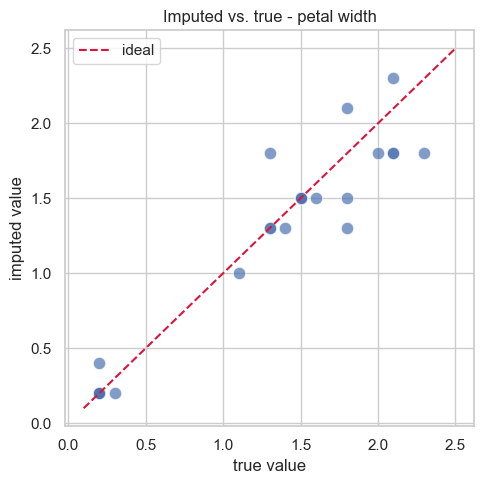

In [5]:
lo, hi = float(frame[target_col].min()), float(frame[target_col].max())

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=truth, y=imputed, ax=ax, s=80, alpha=0.7)
ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--", label="ideal")
ax.set_xlabel("true value")
ax.set_ylabel("imputed value")
ax.set_title(f"Imputed vs. true - {target_col}")
ax.legend()
plt.tight_layout()
plt.show()

## Distribution: real vs. imputed

If the imputer recovered the conditional well, the imputed cells should follow the same shape as
the real column rather than collapsing onto a single value.

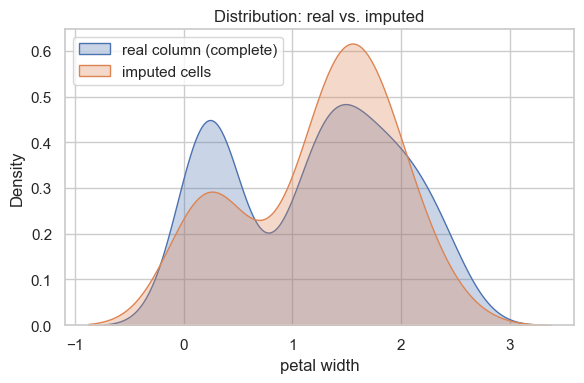

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(frame[target_col], ax=ax, label="real column (complete)", fill=True, alpha=0.3)
sns.kdeplot(imputed, ax=ax, label="imputed cells", fill=True, alpha=0.3)
ax.set_xlabel(target_col)
ax.set_title("Distribution: real vs. imputed")
ax.legend()
plt.tight_layout()
plt.show()